In [1]:
from  src.data_generator import DataGenerator
from src.models import LinearModel
import numpy as np
import matplotlib.pyplot as plt


In [2]:
''' Generating test_dataset also including true values. Kept the seed integer because test data doesnt change'''

error = 0.4 # This is standard deviation of normal distribution.
test_samplesize = 1000

test_data = DataGenerator(error, test_samplesize)
X_test, t_test, t_test_true = test_data.Generate_Non_Linear_Data(42, False, True)

In [6]:
''' 
Starting the Bias_Variance_Tradeoff Experiment. We use Normal Equation in this code to calculate weights. We have not Standarized our data to calculate weights.

1) We take models from degree = 1 to degree = 15. 
2) Number of training datasets used is = 100. 
'''


sample_size = 25 # Number of samples in each training_dataset

training_data = DataGenerator(error, sample_size)
num_of_training_datasets = 100

bias_squared = []
variance = []
raw_mse = []

for d in range(1,16):

    predictions_matrix = np.zeros(shape=(num_of_training_datasets, test_samplesize)) # For every degree we create a Predictions_Matrix which is of order (num_of_training_datasets x test_samplesize). This is because Every Row represent Predictions aganist the weights calculated using that training_dataset

    for l in range(num_of_training_datasets):

        X_train, t_train = training_data.Generate_Non_Linear_Data(None, False, False) # We dont return Standardized X_train and t_train because we are using normal equation to calculate Weights not Gradient Descent. 

        
        # Now training the model

        model = LinearModel(d)
        model.fitNormalEquation(X_train, t_train)

        
        predictions = model.predict(X_test) # We have weights now. Using these weights to calculate Predictions
        predictions_matrix[l,:] = predictions[:,0] # Updating the Predictions_matrix rows. Each row shows Prediction aganist the weights calculated using that training_dataset

    
    # Now doing calculations for Bias_Variance

    expected_predictions = (np.mean(predictions_matrix, axis=0)).reshape(-1,1)

    # Calculation for Bias
    bias_per_point = (expected_predictions - t_test_true)**2
    total_bias_squared = np.mean(bias_per_point) # This will return a scalar value which is avg of bias_per_point
    bias_squared.append(total_bias_squared)

    # Calculation for Variance
    variance_per_point = (np.var(predictions_matrix, axis=0)).reshape(-1,1) # This is a vector
    avg_variance = np.mean(variance_per_point) # This will return a scalar value which is avg of variance_per_point
    variance.append(avg_variance)

    # Calculating raw_mse
    t_test_flattened = t_test.flatten() # Need to flatten the t_test_true so that we dont get numpy broadcasting error
    raw_squared_errors = (predictions_matrix - t_test_flattened)**2
    mse = np.mean(raw_squared_errors)
    raw_mse.append(mse)


# Converting lists to Array for easier calculations

bias_squared_array = np.array(bias_squared)
variance_array = np.array(variance)
raw_mse_array = np.array(raw_mse)

# Now calculating Theoretical Expected(MSE) which is -> (Bias**2 + Variance) + (std_error)**2
theoretical_mse = (bias_squared_array + variance_array) + (error**2)

print(raw_mse)
print(theoretical_mse)


[np.float64(0.4372390073709728), np.float64(0.44353090051445687), np.float64(0.30309649299301583), np.float64(0.3125402715773104), np.float64(0.30230064932975614), np.float64(0.3063456832237183), np.float64(0.3151658322954749), np.float64(0.3160267598057456), np.float64(0.30115840577425323), np.float64(0.30340518665845523), np.float64(0.31591996390344423), np.float64(0.3126943853576984), np.float64(1.8872968842181579), np.float64(0.32341005821263663), np.float64(0.3348286720244373)]
[0.43440937 0.44074485 0.31054515 0.32006907 0.31110433 0.31488546
 0.32652695 0.32711796 0.31136685 0.31353968 0.32760101 0.32416314
 1.89994587 0.33507955 0.34645542]


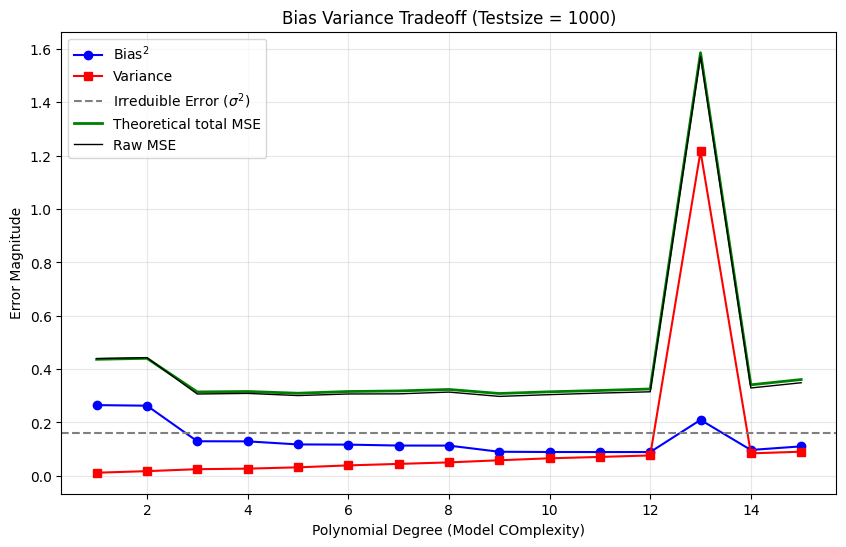

In [ ]:
''' Plotting the Bias_Variance Tradeoff '''

degrees = np.arange(1,16)

# Setting up the canvas
plt.figure(figsize=(10,6))

# Plotting on Canvas
plt.plot(degrees, bias_squared, label='Bias$^2$', color='blue', marker='o')
plt.plot(degrees, variance, label='Variance', color='red', marker='s')


# Adding the irreducilbe error line which is (error**2), variance of error(e)
plt.axhline(y=(error**2), color='gray', linestyle='--', label='Irreduible Error ($\\sigma^2$)') # axhline is matplotlib function to plot a horizontal line on graph

# Plotting Theoritcial MSE and Raw MSE
# Adding line width so that it can be shown that theoretical mse and raw mse overlap.
plt.plot(degrees, theoretical_mse, label='Theoretical total MSE', color='green', linewidth=2)
plt.plot(degrees, raw_mse, label='Raw MSE', color='black', linewidth=1) 

# plt.ylim(0,0.6)

# Formatting the graph
plt.xlabel('Polynomial Degree (Model COmplexity)')
plt.ylabel('Error Magnitude')
plt.title("Bias Variance Tradeoff (Testsize = 1000)")
plt.legend()
plt.grid(True, alpha=0.3)

In [21]:
''' We see overshootinng because of numerical instability of computer. Lets try with standarization now'''

sample_size = 25 # Number of samples in each training_dataset

training_data = DataGenerator(error, sample_size)
num_of_training_datasets = 100

bias_squared = []
variance = []
raw_mse = []

for d in range(1,19):

    predictions_matrix = np.zeros(shape=(num_of_training_datasets, test_samplesize)) # For every degree we create a Predictions_Matrix which is of order (num_of_training_datasets x test_samplesize). This is because Every Row represent Predictions aganist the weights calculated using that training_dataset

    for l in range(num_of_training_datasets):

        X_train_standarized, t_train_standarized = training_data.Generate_Non_Linear_Data(None, True, False) # We return Standardized X_train and t_train because we want to solve the problem of numerical instabilty

        # Now training the model

        model = LinearModel(d)
        model.fitNormalEquation(X_train_standarized, t_train_standarized)

        # Before running predictions on X_test we need to standarize it aswell 
        X_test_standarized = (X_test - training_data.training_input_mean)/training_data.training_input_std


        predictions = model.predict(X_test_standarized) # We have weights now. Using these weights to calculate Predictions

        # Before updating predictions to predcitions_matrix we need to get our predictions back to original value using denormalize() function

        org_predictions = training_data.denormalize(predictions)


        predictions_matrix[l,:] = org_predictions[:,0] # Updating the Predictions_matrix rows. Each row shows Prediction aganist the weights calculated using that training_dataset

    
    # Now doing calculations for Bias_Variance

    expected_predictions = (np.mean(predictions_matrix, axis=0)).reshape(-1,1)

    # Calculation for Bias
    bias_per_point = (expected_predictions - t_test_true)**2
    total_bias_squared = np.mean(bias_per_point) # This will return a scalar value which is avg of bias_per_point
    bias_squared.append(total_bias_squared)

    # Calculation for Variance
    variance_per_point = (np.var(predictions_matrix, axis=0)).reshape(-1,1) # This is a vector
    avg_variance = np.mean(variance_per_point) # This will return a scalar value which is avg of variance_per_point
    variance.append(avg_variance)

    # Calculating raw_mse
    t_test_flattened = t_test.flatten() # Need to flatten the t_test_true so that we dont get numpy broadcasting error
    raw_squared_errors = (predictions_matrix - t_test_flattened)**2
    mse = np.mean(raw_squared_errors)
    raw_mse.append(mse)


# Converting lists to Array for easier calculations

bias_squared_array = np.array(bias_squared)
variance_array = np.array(variance)
raw_mse_array = np.array(raw_mse)

# Now calculating Theoretical Expected(MSE) which is -> (Bias**2 + Variance) + (std_error)**2
theoretical_mse = (bias_squared_array + variance_array) + (error**2)


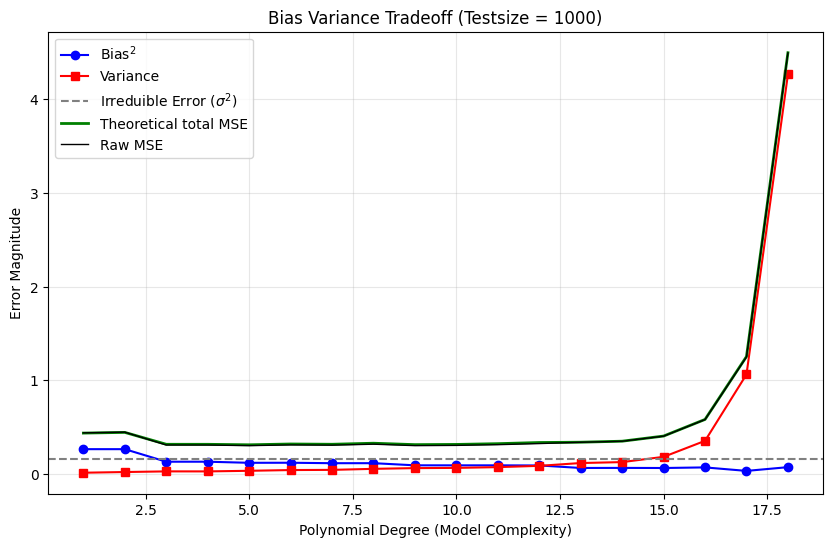

In [22]:
''' Plotting the Bias_Variance Tradeoff '''

degrees = np.arange(1,19)

# Setting up the canvas
plt.figure(figsize=(10,6))

# Plotting on Canvas
plt.plot(degrees, bias_squared, label='Bias$^2$', color='blue', marker='o')
plt.plot(degrees, variance, label='Variance', color='red', marker='s')


# Adding the irreducilbe error line which is (error**2), variance of error(e)
plt.axhline(y=(error**2), color='gray', linestyle='--', label='Irreduible Error ($\\sigma^2$)') # axhline is matplotlib function to plot a horizontal line on graph

# Plotting Theoritcial MSE and Raw MSE
# Adding line width so that it can be shown that theoretical mse and raw mse overlap.
plt.plot(degrees, theoretical_mse, label='Theoretical total MSE', color='green', linewidth=2)
plt.plot(degrees, raw_mse, label='Raw MSE', color='black', linewidth=1) 

# plt.ylim(0,0.6)

# Formatting the graph
plt.xlabel('Polynomial Degree (Model COmplexity)')
plt.ylabel('Error Magnitude')
plt.title("Bias Variance Tradeoff (Testsize = 1000)")
plt.legend()
plt.grid(True, alpha=0.3)